# energiapy example case study 

This is an example implementation of the energiapy python module for decision-making and risk analysis of integrated energy systems.

energiapy relies on the resource task network (RTN) approach:

In the RTN representation, systems can be visualized as transitional elements which convert resources into other resources.
The distinction between and energy and material resources is merely illustrative. Mathematically, resources are treated consistently throughout the framework

The key goals are to:

1. Identify syergies between material and energy supply chains 
2. Propose network designs for future energy systems
3. Perform scenario analysis to identify critical components

The systems modeled in the example case study include:

* dense energy carrier (DEC) production; e.g. hydrogen through electrolysis and methane reforming, production of methanol through a novel catalytic process
* carbon capture, utilization, and sequestration; e.g. direct air capture (DAC), sequestration in aquifers, utilization to produce methanol  
* power generation; e.g. solar, wind, natural gas
* transportation networks; e.g. trains and pipeline for the transport of energy vectors.


__author__ = "Rahul Kakodkar"
__copyright__ = "Copyright 2022, Multi-parametric Optimization & Control Lab"
__credits__ = ["Rahul Kakodkar", "Efstratios N. Pistikopoulos"]
__license__ = "Open"
__version__ = "1.0.0"
__maintainer__ = "Rahul Kakodkar"
__email__ = "cacodcar@tamu.edu"
__status__ = "Production"


![alt text](pictures/energia.png "Title")

$\textbf{Import modules}$

In [1]:
from os import stat
import pandas
from numpy import poly1d, polyfit
from src.energiapy.components.temporal_scale import Temporal_scale
from src.energiapy.components.resource import Resource
from src.energiapy.components.process import Process
from src.energiapy.components.material import Material
from src.energiapy.components.location import Location
from src.energiapy.components.network import Network
from src.energiapy.components.scenario import Scenario
from src.energiapy.components.transport import Transport
from src.energiapy.components.result import Result
from src.energiapy.model.formulate_milp import formulate_milp
from src.energiapy.utils.data_utils import get_data, make_henry_price_df
from src.energiapy.utils.nsrdb_utils import fetch_nsrdb_data
from src.energiapy.plot import plot
from src.energiapy.model.pyomo_solve import solve
from src.energiapy.utils.cluster_utils import reduce_scenario, agg_hierarchial_elbow, Clustermethod
from src.energiapy.utils.data_utils import load_results
import matplotlib.pyplot as plt


$\textbf{Import data}$

The fetch_nsrdb function accesses the National Solar Radiation Database (NSRDB) Highly Scalable Datasets (HSDS) hosted by NREL on a Amazon Web Services (AWS) cloud through the h5py module To access large datasets, an API key can be requested from NREL. 

1. download data at any latitude longitude (globally) or state-county (because of repetition of county names) pairs within the US.

2. Skim and fetch data which match different specifications,  e.g. wind data for collection point at the highest elevation in the county.

3. While HSDS allows you to splice datasets, the script allows you to also find means within ranges.

4. Arrange data in a dataframe for multiscale analysis, with the temporal indices as tuples.  [Can be saved as .csv/.txt/.json/.pkl]

Here, we import solar data as dni and wind data as wind speed for most populated data point in Harris county (TX) and Los Angeles county (CA) at an hourly resolution

In [12]:
weather_dict = {
    'TX' : {county: fetch_nsrdb_data(attrs = ['wind_speed', 'dni'], year = 2020, state = 'Texas', county = county,\
        resolution= 'hourly', get = 'min-population', save = 'data/ho_solar20')[1] for county in ['Harris']}} # 'Galveston']},

    # 'CA' : {county: fetch_nsrdb_data(attrs = ['wind_speed', 'dni'], year = 2019, state = 'California', county = county,\
    #     resolution= 'hourly', get = 'max-elevation')[1] for county in ['San Bernardino', 'Los Angeles', 'Riverside']}
    # }


In [14]:
help(fetch_nsrdb_data)

Help on function fetch_nsrdb_data in module src.energiapy.utils.nsrdb_utils:

fetch_nsrdb_data(attrs: List[str], year: int, lat_lon: Tuple[float] = None, state: str = '', county: str = '', resolution: str = '', get: str = 'max-population', save: str = None) -> Union[pandas.core.frame.DataFrame, tuple]
    fetches nsrdb data from nearest coordinates (latitude, longitude) 
    or from county in a state matching a particular 'get' metric
    
    Args:
        attrs (List[str]): attributes to fetch ['air_temperature',
                                        'clearsky_dhi',
                                        'clearsky_dni',
                                        'clearsky_ghi',
                                        'cloud_type',
                                        'coordinates',
                                        'dew_point',
                                        'dhi',
                                        'dni',
                                        'fill_flag',
  

*import natural gas prices*

Natural gas prices are from the Henry price index at a daily temporal resolution. 

The energia.make_henry_price_df function implicitly fills in gaps in data such as weekends and public holidays by repeating the last recorded prices
For e.g. if the 4th of July will use the price for the 3rd of July
a typical saturday and sunday will take the values for the last friday.

The stretch functionality stretches the values over the hourly temporal scale (8760) from a daily temporal scale (365), again through repetition.  

In [3]:
hp_price_daily_df = make_henry_price_df(
    file_name='data/Henry_Hub_Natural_Gas_Spot_Price_Daily.csv', year=2019, stretch=True)


*import cost data*

The costing data for Lithium ion batteries, Solar PVs, Wind Farms, and pumped storage hydropower (PSH) are from the NREL annual technology baseline 2021

The rest of the costing data is from assorted sources as stated

Technology costs have three components: Capital expenditure (CAPEX), fixed operation and management expenditure (Fixed O&M), and variable operation and management expenditure (Variable O&M)

The costing is done with respect to a defined basis for each process. 

Note that this is done for the sake of ease, the prices can also be introduced directly to a process class object

In [4]:
cost_dict = get_data(file_name='data/cost_dict')
for i in cost_dict['HO']['moderate'].keys():
    print(i + ':', cost_dict['HO']['moderate'][i]['0'])

LiI_c: {'CAPEX': 1302181.81818181, 'Fixed O&M': 41432.7272727272, 'Variable O&M': 0, 'units': '$/MW', 'source': 'NREL Annual Technology Baseline 2021, https://atb.nrel.gov/'}
LiI_d: {'CAPEX': 0.001, 'Fixed O&M': 0.001, 'Variable O&M': 0, 'units': '$/MW', 'source': 'Dummy Process'}
CAES_c: {'CAPEX': 1669000.0, 'Fixed O&M': 16700.0, 'Variable O&M': 0, 'units': '$/MW', 'source': 'https://www.pnm.com/documents/396023/1506047/2017+-+HDR+10-30-17+PNM+Energy+Storage+Report.pdf/a2b7ca65-e1ba-92c8-308a-9a8391a87331'}
CAES_d: {'CAPEX': 0.001, 'Fixed O&M': 0.001, 'Variable O&M': 0, 'units': '$/MW', 'source': 'Dummy Process'}
PSH_c: {'CAPEX': 0, 'Fixed O&M': 41432.7272727272, 'Variable O&M': 4435.188, 'units': '$/MW', 'source': 'NREL Annual Technology Baseline 2021, https://atb.nrel.gov/'}
PSH_d: {'CAPEX': 0.001, 'Fixed O&M': 0.001, 'Variable O&M': 0, 'units': '$/MW', 'source': 'Dummy Process'}
PV: {'CAPEX': 1302181.81818181, 'Fixed O&M': 41432.7272727272, 'Variable O&M': 0, 'units': '$/MW', 'sour

$\textbf{Define temporal scale}$

Temporal_scale is used to define a discretization of the temporal scale

E.g.: A year at annual, daily and hourly descritization cane be represented as:

Annual (1x1 = 1) - network level trends and their inherent uncertainties can be well represented at an annual scale, for example, augmentations in process efficiencies, reductions in technology cost.

Daily (1x365 = 365) - Purchase level decisions can be sufficienctly described at a daily scale.

Hourly (1x365x24 = 8760)- Solar and wind availability can be represented to within some factor of accuracy at an hourly scale.

In [5]:
scales = Temporal_scale(discretization_list=[1, 365, 24])

In [6]:
help(Temporal_scale)

Help on class Temporal_scale in module src.energiapy.components.temporal_scale:

class Temporal_scale(builtins.object)
 |  Temporal_scale(discretization_list: list) -> None
 |  
 |  object with the temporal scales of the problem
 |  e.g.:
 |  scales = temporal_scale(discretization_list = [1, 365, 24]).generate_scales()
 |  Generates three temporal scales with 1, 365, and 24 discretizations respectively
 |  Args:
 |      discretization_list (list): list of discretization of temporal scale
 |  
 |  Methods defined here:
 |  
 |  __eq__(self, other)
 |      Return self==value.
 |  
 |  __hash__(self)
 |      Return hash(self).
 |  
 |  __init__(self, discretization_list: list) -> None
 |      Initialize self.  See help(type(self)) for accurate signature.
 |  
 |  __post_init__(self)
 |  
 |  __repr__(self)
 |      Return repr(self).
 |  
 |  ----------------------------------------------------------------------
 |  Data descriptors defined here:
 |  
 |  __dict__
 |      dictionary for in

$\textbf{Declare constants for ease}$


In [6]:
bigM = 10**3  # very large number
smallM = 0.1
water_price = 31.70  # $/5000gallons
power_price = 8  # cents/kWh
ur_price = 42.70  # 250 Pfund U308 (Uranium)
A_f = 0.05  # annualization factor
# CO2_res = 0.2
pv_start = 0
ake_start = 0
smrh_start = 0
smr_start = 0
asmr_start = 0

$\textbf{Declare resources}$

Resources can be -

$\textit{consumed}$, e.g. solar, wind

$\textit{purchased}$ (consumed at a cost), e.g. natural gas, water

$\textit{sold}$, e.g. hydrogen, power

$\textit{produced}$, e.g. hydrogen, methanol

$\textit{stored}$, e.g. power as charge or elevated water, hydrogen as cryogenic or compressed

$\textit{discharged}$ (sold for 0 currency), e.g. CO2, O2 (could be assigned profit)

basis can be declared, maximum consumption and storage can be defined

selling and purchase costs can vary. Natural gas and power for example

labels and blocks can be defined

these can be represented as cost factors (0,1) multiplied to a base resource cost


In [22]:
help(Resource)

Help on class Resource in module src.energiapy.components.resource:

class Resource(builtins.object)
 |  Resource(name: str, label: str = '', cons_max: float = 0, loss: float = 0, revenue: float = 0, price: float = 0, mile: float = 0, store_max: float = 0, store_min: float = 0.01, sell: bool = False, demand: bool = False, basis: str = 'unit', block: str = None, citation: str = 'citation needed', varying: bool = False, varying_cost_df: pandas.core.frame.DataFrame = None) -> None
 |  
 |  Object with resource data
 |  
 |  Args:
 |      name (str): ID for the resource
 |      label (str, optional): name of the resource. Defaults to ''.
 |      consumption_max (float, optional): Maximum allowed resource consumption in time period [unit/h]. Defaults to 0.
 |      loss (float, optional): Amount of resource lost in time period [h]. Defaults to 0.
 |      revenue (float, optional): Amount earned through sale of resource [$/unit]. Defaults to 0.
 |      price (float, optional): Purchase cost o

In [7]:

Charge = Resource(name='Charge', sell=False,
                  store_max=bigM, basis='MW', label='Battery energy', block='energystorage')
Solar = Resource(
    name='Solar', cons_max=bigM, basis='MW', label='Solar Power', block='energyfeedstock')
Wind = Resource(name='Wind', cons_max= bigM, basis='MW', label='Wind Power', block='energyfeedstock')
H2_L = Resource(name='H2_L', store_max=10**10, revenue=2,
                mile=1/(0.1180535*1.60934), basis='kg', label='Hydrogen - Geological', block='resourcestorage')
# H2 = Resource(name='H2', basis='kg', sell = True, demand = True, label='Hydrogen', block='Resource')
H2 = Resource(name='H2', basis='kg', label='Hydrogen', block='Resource', demand = True, sell = True)

H2O = Resource(name='H2O', cons_max=10**10,
               price= 0.001, basis='kg', label='Water', block='Resource')
            #    price=water_price/(5000*3.7854), basis='kg', label='Water', block='Resource')
O2 = Resource(name='O2', sell=True, loss=0.07,
              basis='kg', label='Oxygen', block='Resource')
CH4 = Resource(name='CH4', cons_max=10 **
               10, price=1, basis='kg', label='Natural gas', block='materialfeedstock', varying_cost_df=hp_price_daily_df)
CO2 = Resource(name='CO2', basis='kg',
               label='Carbon dioxide', block='Resource')
CO2_Vent = Resource(
    name='CO2_Vent', sell=True, basis='kg', label='Carbon dioxide - Vented', block='resourcedischarge')
# Power= Resource(name= 'Power', sell= True, store_max=0,   \
#    mile= (10**3)/(0.2167432**1.60934), label= 'Renewable power generated')
Power = Resource(name='Power', basis='MW',
                 label='Renewable power generated', block='Resource')
# Mile = Resource(name = 'Mile', basis = 'miles', sell = True, demand  = True, label = 'miles driven')

$\textbf{Declare materials}$

In [8]:
Li = Material(name='Li', gwp=0, basis='kg', label='Lithium')

In [7]:
help(Material)

Help on class Material in module src.energiapy.components.material:

class Material(builtins.object)
 |  Material(name: str, label: str = '', gwp: tuple = None, basis: str = 'unit', citation: str = 'citation needed', H2O: float = 0) -> None
 |  
 |  Object with data regarding infrastructure material
 |  
 |  Args:
 |      name (str): ID 
 |      basis (str): base unit for calculation
 |      label (str, optional): name of the material. Defaults to ''.
 |      gwp (float, optional): global warming potential. Defaults to 0.
 |      citation (str, optional): add citation. Defaults to 'citation needed'.
 |  
 |  Methods defined here:
 |  
 |  __eq__(self, other)
 |      Return self==value.
 |  
 |  __hash__(self)
 |      Return hash(self).
 |  
 |  __init__(self, name: str, label: str = '', gwp: tuple = None, basis: str = 'unit', citation: str = 'citation needed', H2O: float = 0) -> None
 |      Initialize self.  See help(type(self)) for accurate signature.
 |  
 |  __post_init__(self)
 | 

$\textbf{Declare processes}$

Processes can convert resources, for example electorlysis converts water and power into hydrogen.

processes also require materials such as Lithium for Li-ion batteries

production capacity could be subject to variation. e.g. Solar PVs and Wind farms

intermittency can be represented through capacity factors (0,1)

production costs and their trajectories can be defined

blocks can be defined

TRL trajectories can be defined

citations and sources can be added


In [8]:
LiI_c = Process(name='LiI_c', conversion={Charge: 1, Power: -1}, cost = cost_dict['HO']['moderate']['LiI_c']['0'],\
    prod_max=10000, trl='nrel', block='power_storage', label='Lithium-ion battery', citation='Zakeri 2015')
LiI_d = Process(name='LiI_d', conversion={Charge: -1.1765, Power: 1}, cost =  {'CAPEX': smallM, 'Fixed O&M': 0, 'Variable O&M': smallM, \
    'units': '$/kg','source': 'dummy'}, \
    prod_max=10000, trl='discharge', block='power_storage', label='Lithium-ion battery discharge', citation='Zakeri 2015')
WF = Process(name='WF', conversion={Wind: -1, Power: 1, H2O: -1}, cost=cost_dict['HO']['moderate']['WF']['0'],
             prod_max=10000, gwp=52700, land=10800/1800, trl='nrel', block='power_generation',
             label='Wind mill array', citation='Use windtoolkit conversion', varying_capacity_df=weather_dict['TX']['Harris']['wind_speed'], p_fail= 0.05)
PV = Process(name='PV', intro_scale=pv_start, conversion={Solar: -1, Power: 1, H2O: -20}, cost=cost_dict['HO']['moderate']['PV']['0'],
             prod_max=bigM, gwp=53000, land=13320/1800, trl='nrel', block='power_generation', \
                 label='Solar photovoltaics (PV) array', citation='Use pvlib conversion', varying_capacity_df=weather_dict['TX']['Harris']['dni'], p_fail = 0.05)
AKE = Process(name='AKE', intro_scale=ake_start, conversion={Power: -1, H2: 19.474, O2: 763.2, H2O: -175.266},
              cost= {'CAPEX': 7840000.0, 'Fixed O&M': 17000.0, 'Variable O&M': 0, 'units': '$/MW', 'source': 'https://www.cell.com/cell-reports-physical-science/pdfExtended/S2666-3864(20)30224-1'}, prod_max=bigM, trl='utility', block='material_production',
              label='Alkaline water electrolysis (AWE)', citation='Demirhan et al. 2018 AIChE paper', p_fail= 0.05)  # 20.833 MW required to produce 1000t/day.H2
SMR = Process(name='SMR', intro_scale=smr_start, cost= {'CAPEX': 2400, 'Fixed O&M': 800, 'Variable O&M': 0.05, 'units': '$/kg', 'source': 'dummy'}, \
    conversion={Power: -1.11*10**(-3), CH4: -3.76, H2O: -23.7, H2: 1, CO2_Vent: 9.4979}, prod_max=bigM, gwp=0, trl='enterprise',
                      block='material_production', label='Steam methane reforming', citation='Mosca 2020', p_fail= 0.05)
H2_L_c = Process(name='H2_L_c', conversion={Power: -4.17*10**(-4), H2_L: 1, H2: -1}, cost={'CAPEX': 1000, 'Fixed O&M': 600, 'Variable O&M': 0.05,
                                                                                           'units': '$/kg', 'source': 'dummy'},
                 prod_max=bigM, gwp=0, trl='repurposed', block='material_storage', label='Hydrogen geological storage',
                 citation='Bossel and Eliasson - Energy and the Hydrogen Economy', p_fail= 0.05)
H2_L_d = Process(name='H2_L_d', conversion={H2_L: -1, H2: 1}, prod_max=bigM, gwp=0, trl='nocost', cost={'CAPEX': smallM, 'Fixed O&M': 0, 'Variable O&M': 1,   
                                                                                                        'units': '$/kg', 'source': 'dummy'},
                 block='material_storage', label='Hydrogen geological storage discharge', citation='Bossel and Eliasson - Energy and the Hydrogen Economy', p_fail= 0.01)
# EV = Process(name = 'EV', conversion = {Power: -0.00025, Mile: 1}, prod_max= bigM, gwp = 0, \
#     cost={'CAPEX': smallM, 'Fixed O&M': 0, 'Variable O&M': 1, 'units': '$/kg', 'source': 'dummy'}, label = 'electric vehicle')
# HV = Process(name = 'HV', conversion = {H2: -0.037, Mile: 1}, prod_max= bigM, gwp = 0, \
#     cost={'CAPEX': smallM, 'Fixed O&M': 0, 'Variable O&M': 1, 'units': '$/kg', 'source': 'dummy'}, label = 'hydrogen vehicle')


$\textbf{Declare demand dictionary}$

Here a daily demand of x kgs is being met, the resources to meet the demand are drawn from the resource object [demand = True]

Note that different demands for different resources at different locations can be specified. 

In the absence of resource-specific demands, all the resources which have demand set as True are used

In [9]:
ho_demand_dict = {(0, i): 1.0*10**3 for i in range(scales.discretization_list[1])}
# la_demand_dict = {(0, i): 1.0*10**3 for i in range(scales.discretization_list[1])}

$\textbf{Declare location(s)}$

Location(s) is defined using a set of processes.

energiapy internally collects all the resources and materials required at location

The demand at each location needs to be introduced 




In [10]:
HO = Location(name='HO', processes={LiI_c, LiI_d, PV, WF, AKE,
                 H2_L_c, H2_L_d, SMR}, demand= ho_demand_dict, scales=scales, label='Houston')
# LA = Location(name='LA', processes= {H2_L_c, H2_L_d, PV, LiI_c, LiI_d, WF, H2_Blue, H2_Green, H2_C_d, H2_L_d, AQoff_SMR, EOR, SMRH}, demand= la_demand_dict, scales = scales, label='Los Angeles')

$\textbf{Plot varying data input}$

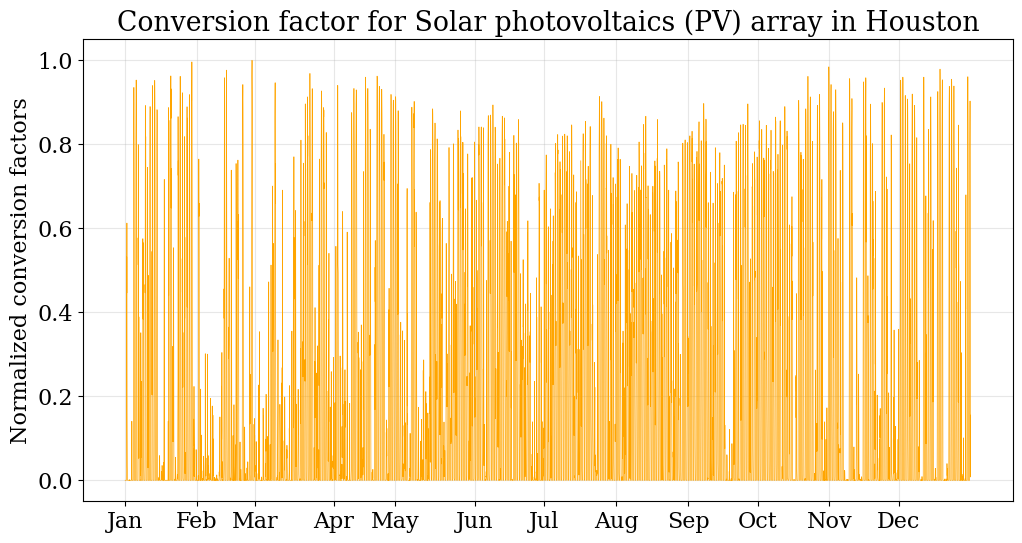

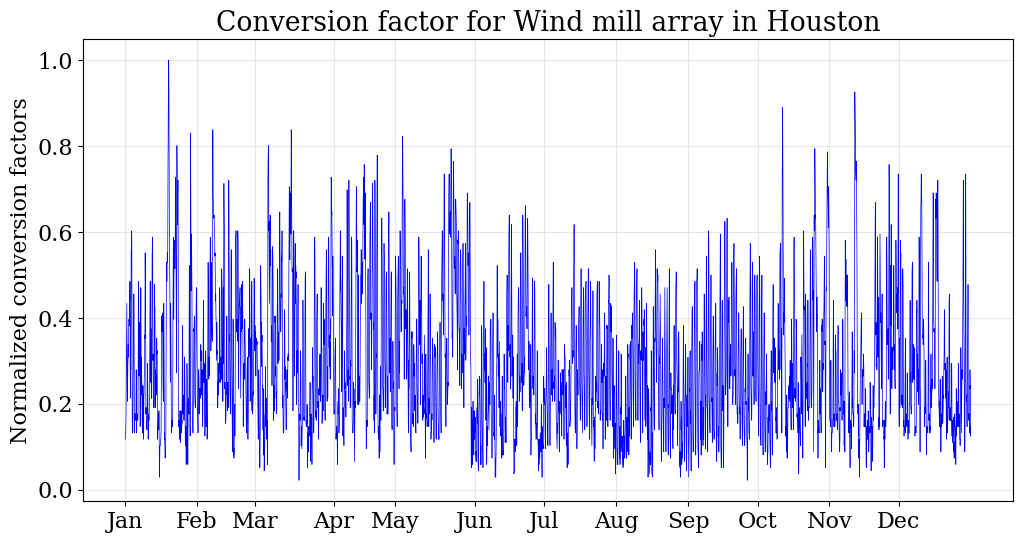

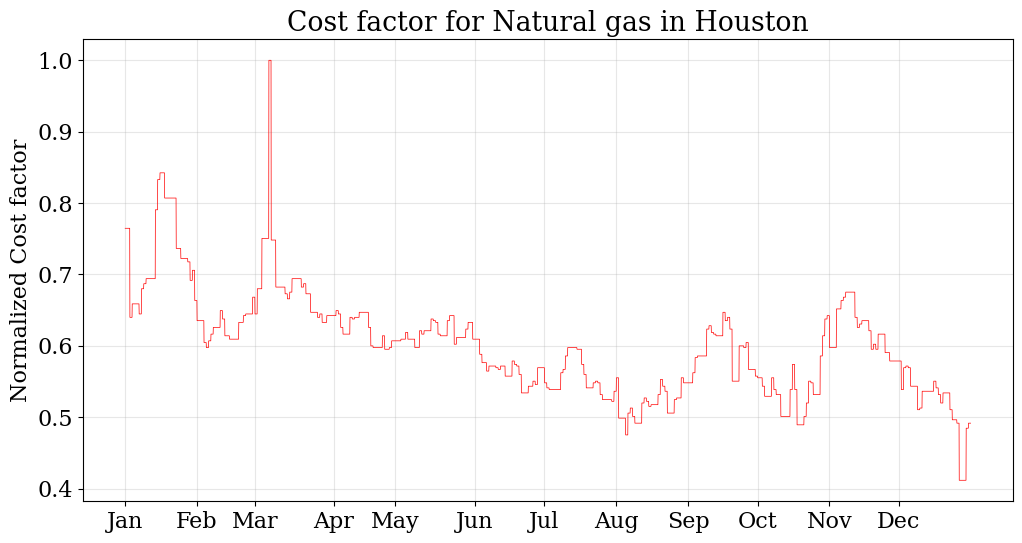

In [12]:
plot.capacity_factor(location= HO, process= PV, color= 'orange')
plot.capacity_factor(location= HO, process= WF, color= 'blue')
plot.cost_factor (location= HO, resource= CH4, color= 'red')

$\textbf{Declare transport modes}$

Transport modes are defined by the resources they carry, the cost of transportation, maximum capacity, and storage losses

In [30]:
Train_H2 = Transport(name= 'Train_H2', resources= {H2_L}, trans_max= 100, trans_loss= 0.001, trans_cost= 1.667*10**(-3)\
    , label= 'Railway for hydrogen transportation')
Pipe = Transport(name= 'Pipe', resources= {H2_L}, trans_max= 100, trans_loss= 0.001, trans_cost= 0.5*10**(-3), label= 'Railroad transport')

$\textbf{Declare network between locations}$

Networks are defined by the source and sink locations and the distance and transport matrix connecting them.

A single location problem does not need a Network object to be defined

In [15]:
distance_matrix = [
    [0, 678],
    [678, 0]
                   ]

transport_matrix = [
    [[], [Train_H2, Pipe]],
    [[Train_H2, Pipe], []] 
                   ]

network = Network(name= 'Network', source_locations= [HO, LA], sink_locations= [HO, LA], distance_matrix= distance_matrix, transport_matrix= transport_matrix) 


NameError: name 'LA' is not defined


$\textbf{Generate full-scale scenario}$

$\textit{Multi-location scenario}$

Scenarios are declared either using a network or a location. 

In [16]:

case_ml = Scenario(name= 'shell', network= network, scales= scales,  expenditure_scale_level= 2, scheduling_scale_level= 2, \
    network_scale_level= 0, demand_scale_level= 1, label= 'shell milp case study')

$\textit{Single location scenario}$

For a single location problem, the network can be declared as a single location.


In [13]:
case_ho = Scenario(name= 'shell', network= HO, scales= scales,  expenditure_scale_level= 2, scheduling_scale_level= 2, \
    network_scale_level= 0, demand_scale_level= 1, label= 'shell milp case study (HO)')
# case_la = Scenario(name= 'shell', network= LA, scales= scales,  expenditure_scale_level= 2, scheduling_scale_level= 2, \
#     network_scale_level= 0, demand_scale_level= 1, label= 'shell milp case study (LA)')

$\textbf{Determine the elbow point for clustering}$

The agg_hierarchial_elbow() determines the within ward cluster variance for a given range

The elbow point can then be identified 

In [ ]:
range_l = 10
range_u = 60
error_dict = {
     'HO': {
          'cof': agg_hierarchial_elbow(scales = scales, scale_level= 1, cost_factor= case_ho.cost_factor['HO'], range_list= range(range_l, range_u)),
          'caf': agg_hierarchial_elbow(scales = scales, scale_level= 1, capacity_factor= case_ho.capacity_factor['HO'], range_list= range(range_l, range_u)),
          'wf': agg_hierarchial_elbow(scales = scales, scale_level= 1, capacity_factor= {'WF_HO': case_ho.capacity_factor['HO']['WF_HO']}, range_list= range(range_l, range_u)),
          'pv': agg_hierarchial_elbow(scales = scales, scale_level= 1, capacity_factor= {'PV_HO': case_ho.capacity_factor['HO']['PV_HO']}, range_list= range(range_l, range_u)),
          'all': agg_hierarchial_elbow(scales = scales, scale_level= 1, cost_factor= case_ho.cost_factor['HO'], capacity_factor= case_ho.capacity_factor['HO'], range_list= range(range_l, range_u))
     },
     
     'LA': {
          'cof': agg_hierarchial_elbow(scales = scales, scale_level= 1, cost_factor= case_la.cost_factor['LA'], range_list= range(range_l, range_u)),
          'caf': agg_hierarchial_elbow(scales = scales, scale_level= 1, capacity_factor= case_la.capacity_factor['LA'], range_list= range(range_l, range_u)),
          'wf': agg_hierarchial_elbow(scales = scales, scale_level= 1, capacity_factor= {'WF_LA': case_la.capacity_factor['LA']['WF_LA']}, range_list= range(range_l, range_u)),
          'pv': agg_hierarchial_elbow(scales = scales, scale_level= 1, capacity_factor= {'PV_LA': case_la.capacity_factor['LA']['PV_LA']}, range_list= range(range_l, range_u)),
          'all': agg_hierarchial_elbow(scales = scales, scale_level= 1, cost_factor= case_la.cost_factor['LA'], capacity_factor= case_la.capacity_factor['LA'], range_list= range(range_l, range_u))
     }     
}

In [ ]:
fig, ax = plt.subplots(nrows = 2, ncols = 5, figsize = (20,10))
for i,j in zip(range(len(error_dict['HO'].keys())), error_dict['HO'].keys()) :
    ax[0, i].plot(error_dict['HO'][j])
    ax[0, i].set_title(j)
    
for i,j in zip(range(len(error_dict['LA'].keys())), error_dict['LA'].keys()) :
    ax[1, i].plot(error_dict['LA'][j])
    ax[1, i].set_title(j)
    

In [ ]:
fit = lambda a: poly1d(polyfit(x = list(range(len(a))), y = a, deg = 3))

fit_dict = {
    'HO': {i: fit(error_dict['HO'][i]) for i in error_dict['HO'].keys()},
    'LA': {i: fit(error_dict['LA'][i]) for i in error_dict['LA'].keys()},    
}

# yline = lambda a,b: [a[j]*pow(i,j) + a[1] * pow(i, 1) + a[2] * pow(i, 2) + a[3]*pow(i, 3) for i in list(range(len(b)))]
yline = lambda a,b,deg: [sum(a[j]*pow(i,j) for j in range(deg)) for i in list(range(len(b)))]

yline_dict = {
    'HO': {i: yline(fit_dict['HO'][i], error_dict['HO'][i], 3) for i in error_dict['HO'].keys()},
    'LA': {i: yline(fit_dict['LA'][i], error_dict['LA'][i], 3) for i in error_dict['LA'].keys()},    
}

In [ ]:
fit = lambda a: poly1d(polyfit(x = list(range(len(a))), y = a, deg = 2))

fit_dict = {
    'HO': {i: fit(error_dict['HO'][i]) for i in error_dict['HO'].keys()},
    'LA': {i: fit(error_dict['LA'][i]) for i in error_dict['LA'].keys()},    
}

yline = lambda a,b: [a[0] + a[1] * pow(i, 1) + a[2] * pow(i, 2) for i in range(len(b))]

yline_dict = {
    'HO': {i: yline(fit_dict['HO'][i], error_dict['HO'][i]) for i in error_dict['HO'].keys()},
    'LA': {i: yline(fit_dict['LA'][i], error_dict['LA'][i]) for i in error_dict['LA'].keys()},    
}

In [ ]:
titles_dict ={
    'cof': 'natural gas',
    'caf': 'wind + solar',
    'wf': 'wind',
    'pv': 'solar',
    'all': 'wind + solar + ng'
    
}

fig, ax = plt.subplots(nrows = 2, ncols = 5, figsize = (20,10))
for i,j in zip(range(len(yline_dict['HO'].keys())), yline_dict['HO'].keys()) :
    ax[0, i].plot(yline_dict['HO'][j])
    ax[0, i].set_title(titles_dict[j])
    
for i,j in zip(range(len(yline_dict['LA'].keys())), yline_dict['LA'].keys()) :
    ax[1, i].plot(yline_dict['LA'][j])
    ax[1, i].set_title(titles_dict[j])
    
for i,j in zip(range(len(error_dict['HO'].keys())), error_dict['HO'].keys()) :
    ax[0, i].plot(error_dict['HO'][j])
    ax[0, i].set_title(titles_dict[j])
    
for i,j in zip(range(len(error_dict['LA'].keys())), error_dict['LA'].keys()) :
    ax[1, i].plot(error_dict['LA'][j])
    ax[1, i].set_title(titles_dict[j])
    

$\textbf{Reduce full-scale scenario}$

The reduce_scenario function allows for the clustering of the temporal scale using a chosen method.

Here, agglomerative hierarchial clustering (AHC) is used to generate 20 representative days

In [ ]:
from src.energiapy.utils.cluster_utils import agg_hierarchial
agg_ho = agg_hierarchial(scales = scales, scale_level = 1, periods = 5, cost_factor = case_ho.cost_factor['HO'], capacity_factor= case_ho.capacity_factor['HO']) 
agg_la = agg_hierarchial(scales = scales, scale_level = 1, periods = 4, cost_factor = case_la.cost_factor['LA'], capacity_factor= case_la.capacity_factor['LA']) 


In [ ]:
ho_list = [case_ho.capacity_factor['HO']['PV_HO'][agg_ho[0][i]['rep_period']] for i in agg_ho[0].keys()]
la_list = [case_la.capacity_factor['LA']['PV_LA'][agg_la[0][i]['rep_period']] for i in agg_la[0].keys()]
len(ho_list), len(la_list) 

In [ ]:
from src.energiapy.utils.cluster_utils import dtw_cluster, find_dtw_path

dtw_matrix = dtw_cluster(ho_list, la_list)
dtw_path = find_dtw_path(dtw_matrix)
len(dtw_path)


In [ ]:
x = [i[0] for i in dtw_path]
y = [i[1] for i in dtw_path]
len(x), len(y)

In [ ]:
from numpy import unique
x_n = unique(x)
y_n = unique(y)
len(x_n), len(y_n)

In [14]:

reduced_case_ho = reduce_scenario(
    scenario=case_ho, location=HO, periods=20, scale_level=1, method=Clustermethod.agg_hierarchial)

# reduced_case_la = reduce_scenario(
#     scenario=case_la, location=LA, periods=16, scale_level=1, method=Clustermethod.agg_hierarchial)

In [ ]:
network.source_locations

In [ ]:
reduced_case_ml = reduce_scenario(
    scenario=case_la, location=network, periods={'HO':20, 'LA':20}, scale_level=1, method='agg_hierarchial')

In [ ]:
reduced_case_ho.capacity_factor

$\textbf{Formulate model}$

A pyomo instance is formulated from the scenario

Concises sets and corresponding variables are declared.

Corresponding constraints are generated based on the nature of model chosen

In the presented example, a MILP is formulated



$\textit{Multi-location model formulation}$

In [17]:
milp_ml = formulate_milp(scenario= case_ml)


----------------------------------------------------------------------
inventory balance constraint at 0x000001BCF05B5360>


<IPython.core.display.Math object>

----------------------------------------------------------------------
----------------------------------------------------------------------
nameplate production constraint


<IPython.core.display.Math object>

----------------------------------------------------------------------
----------------------------------------------------------------------
nameplate inventory constraint


...

----------------------------------------------------------------------
----------------------------------------------------------------------
transport cost network constraint


<IPython.core.display.Math object>

----------------------------------------------------------------------
----------------------------------------------------------------------
cost objective


<IPython.core.display.Math object>

----------------------------------------------------------------------


$\textit{Reduced single location model}$

In [15]:
reduced_milp_sl = formulate_milp(scenario= reduced_case_ho)

$\textbf{Solve model}$

The solve functionalty needs the provision of a scenario and a model framework.

Solvers can be chosen, and results can be saved in various formats, viz. .pkl, .txt, .json

$\textit{Multi-location scenario}$

In [18]:
results_ml = solve(scenario = case_ml, instance=milp_ml, solver= 'gurobi', name='example_ml2', print_solversteps = True)

Gurobi Optimizer version 9.5.2 build v9.5.2rc0 (win64)
Thread count: 4 physical cores, 8 logical processors, using up to 8 threads
Optimize a model with 1752354 rows, 1384443 columns and 4477576 nonzeros
Model fingerprint: 0x75c80b51
Variable types: 1384391 continuous, 52 integer (52 binary)
Coefficient statistics:
  Matrix range     [1e-06, 1e+10]
  Objective range  [1e+00, 1e+00]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+02, 1e+06]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 39 rows and 140208 columns (presolve time = 6s) ...
Presolve removed 1173615 rows and 867022 columns
Presolve time: 6.78s

Explored 0 nodes (0 simplex iterations) in 7.84 seconds (1.76 work units)
Thread count was 1 (of 8 available processors)

Solution count 0

Model is infeasible
Best objective -, best bound -, gap -
    model.name="unknown";
      - termination condition: infeasible
      - message from solver: <und

$\textit{Single location scenario}$

In [16]:

results_sl = solve(scenario = case_sl, instance=milp_sl, solver= 'gurobi', name='example_sl', print_solversteps = True)

NameError: name 'case_sl' is not defined

$\textit{Reduced single location scenario}$

In [17]:
results_reduced_sl = solve(scenario = reduced_case_ho, instance= reduced_milp_sl, solver= 'gurobi', name='example_reduced_sl',\
    saveformat= '.pkl', print_solversteps = True)

Gurobi Optimizer version 9.5.2 build v9.5.2rc0 (win64)
Thread count: 4 physical cores, 8 logical processors, using up to 8 threads
Optimize a model with 14020 rows, 10180 columns and 40702 nonzeros
Model fingerprint: 0xde1b0f23
Variable types: 10170 continuous, 10 integer (10 binary)
Coefficient statistics:
  Matrix range     [4e-04, 1e+10]
  Objective range  [1e+00, 1e+00]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+03, 1e+10]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 8544 rows and 5664 columns
Presolve time: 0.03s
Presolved: 5476 rows, 4516 columns, 15933 nonzeros
Variable types: 4509 continuous, 7 integer (7 binary)

Root relaxation: objective 4.026840e+07, 4543 iterations, 0.21 seconds (0.23 work units)

    Nodes    |    Current Node    |     Objective Bounds      |     Work
 Expl Unexpl |  Obj  Depth IntInf | Incumbent    BestBd   Gap | It/Node Time

*    0     0               0    4.0

$\textbf{Load saved results}$

In [ ]:
results = load_results(filename = 'example_reduced_sl.pkl')

$\textbf{Graphing results}$

$\textit{Scheduling results}$

Can be generated at the index of the variable for any component at any location

In [ ]:
graph.schedule(results=results_ml, y_axis='S',
               component='WF', location='HO', usetex=True)

$\textit{Contribution}$

The contribution of different components to a particular variable value can be visualized

In [ ]:
graph.contribution(results=results_ml, y_axis='S_location', location='LA')

$\textit{Capacity Utilization}$

The capacity utilized can be visualized 

In [ ]:
graph.capacity_utilization(results=results_ml, location='HO')


If a particular component is provided, the utilization over a lower scale is graphed

In [ ]:
graph.capacity_utilization(results=results_reduced_sl, location='HO', process='WF_HO')


In [ ]:
results_ml.model_summary()

In [ ]:
results_ml.output.keys()

In [ ]:
results_ml.output['objective']

In [ ]:
help(Result)